<div style="background:#FFFFC5; border:1px solid #000000; padding:5px 10px; color:#000000;">
    <strong>Attention:</strong> The GES DISC THREDDS Service previously used in this notebook has been discontinued. To learn more about the Cloud OPeNDAP service now used in this tutorial, please visit: <a href="https://disc.gsfc.nasa.gov/information/tools?title=OPeNDAP%20In%20The%20Cloud">OPeNDAP in the Cloud.</a>
</div>

# How to remotely access MERRA-2 with Python3 and calculate monthly average surface PM2.5 for world countries

### Overview ###
This python jupyter notebook processes monthly mean surface PM2.5 concentrations. In this example, the monthly MERRA-2 aerosol components are read remotely from the THREDDS Data Server. PM2.5 is calculated as the sum of individual aerosol components (organic carbon, black carbon, sulfate, sea salt, and dust). PM2.5 is recast from the native MERRA-2 model grid to geographic areas of interest. Here, examples are shown aggregating PM2.5 for world countries and territories. Results are exported in tabular format to a comma separate values (csv) file.  In step 3, the US county mask file is for only aggregating PM2.5 values for US counties.

### Example ###

**Data collection:** <br /> 
MERRA-2 tavgM_2d_aer_Nx: 2d,Monthly,Time-averaged,Single-Level,Assimilation,Aerosol Diagnostics V5.12.4 (M2TMNXAER) 

**Variables:** 
BCSMASS, OCSMASS, SO4SMASS, DUSMASS25, SSSMASS25

**Temporal Range:**
January 1 2018 - December 31 2019

**Estimated time used to complete:**
It takes ~2.0 min to run this notebook, not including the time to set up the required data access credentials or downloading mask files.

### Prerequisites

This notebook was written using Python 3.10, and requires:
- Valid [Earthdata Login credentials](https://urs.earthdata.nasa.gov), and the generation of [Earthdata Prerequisite Files](https://disc.gsfc.nasa.gov/information/howto?title=How%20to%20Generate%20Earthdata%20Prerequisite%20Files) including the <code>.netrc</code> and `.dodsrc` files.
- [Xarray](https://docs.xarray.dev/en/stable/)
- [NumPy](https://numpy.org/)
- [Matplotlib](https://matplotlib.org/)
- [Pandas](https://pandas.pydata.org/getting_started.html)
- [Plotly](https://plotly.com/python/getting-started/)
- [netcdf4-python v1.6.2](https://pypi.org/project/netCDF4/1.6.2/)
   - ***Note:*** Other versions of this library may cause access errors, despite valid `.netrc`/`.dodsrc` files
- Download Mask files for world countries and territories (mask_worldCountry_MERRA2.nc) and mask for world population (mask_worldPopulation_MERRA2.nc) on the MERRA-2 grid. Files were generated by Christoph Keller. Files can be downloaded from [archived ancillary file](https://goldsmr4.gesdisc.eosdis.nasa.gov/data/MERRA2_CLIM/M2_TMAX_PM25.1/1980/). Place the mask files in your working directory.  For PM2.5 of US counties, download the US county mask file (mask_UScounty_MERRA2.nc). 
- Download [world geosjon file](https://geojson-maps.kyd.au/) for plotting PM2.5 map in the Procedures Step 6. Be sure to select every check box before downloading, and save the file as `custom.geo.json`.

#### Recommended Anaconda Environment YAML:

We strongly recommend using this ['nasa-gesdisc' Anaconda environment](https://github.com/nasa/gesdisc-tutorials/tree/main/environments/nasa-gesdisc.yml) provided in the 'environments' subfolder.

Please follow the instructions [here](https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html#creating-an-environment-from-an-environment-yml-file) to install and activate this environment. 

### 1. Import libraries, set the working directory, and create a folder to save CSV files:**

In [1]:
import os
import json as json
from datetime import datetime
import earthaccess
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from terra_ui_components import TerraEarthdataLogin
import warnings
warnings.filterwarnings("ignore")
%matplotlib widget

###set your working directory under your HOME directory, e.g.
# C:\Users\Username\MyWorkingDir # on windows

###This step is creating a new folder to save .csv files in the working directory.
###This is where the processed csv files will be saved
### Please change the path in "newpath" to your working dir path
today = datetime.today()
newpath =r'MERRA2_'+today.strftime('%Y-%m-%d') 
if not os.path.exists(newpath):
    os.makedirs(newpath)

### 2. Authenticate with Earthdata Login

This step will prompt for Earthdata Login credentials to retrieve a token that will be used to authenticate with Earthdata Cloud OPeNDAP servers.

In [5]:
auth = earthaccess.login(strategy="interactive", persist=True)

### 3. Search and Load Cloud OPeNDAP URLs

Next, we specify the shortname, version, and temporal parameters in order to search and subset our OPeNDAP URLs.

In [2]:
# Define desired latitude/longitude bounding box
# Global: lat = [-90.0 ,  90.0] degrees N
#         lon = [-180.0, 180.0] degrees E
#
# US    : lat = [24.5  ,  50.0] degrees N
#         lon = [-125.0,-66.25] degrees E    
lat1 = -90.0; lat2= 90.0
lon1 = -180.0; lon2 = 180.0

# Define desired date range
time1 = datetime(2018, 1, 1, 0, 30, 0)
time2 = datetime(2019, 12, 1, 0, 30, 0)

# Search for OPeNDAP URLs
results = earthaccess.search_data(
    short_name="M2TMNXAER",
    version='5.12.4',
    temporal=('2018-01-01', '2019-12-01'),
    bounding_box=(-180, 0, 180, 90)
)

# Parse out URL from request, add to OPeNDAP URLs list for querying multiple granules
od_files = []
for item in results:
    for urls in item['umm']['RelatedUrls']:  # Iterate over RelatedUrls in each request step
        if 'OPENDAP' in urls.get('Description', '').upper():  # Check if 'OPENDAP' is in the Description
            url = urls['URL']
            # Add URL to list
            od_files.append(url)

# Open each OPeNDAP file into a concatenated Xarray dataset object and print metadata
ds = xr.open_mfdataset(od_files)
ds

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 24, lat: 361, lon: 576)
Coordinates:
  * lon            (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * time           (time) datetime64[ns] 192B 2018-01-01T00:30:00 ... 2019-12...
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
Data variables: (12/100)
    Var_SO2SMASS   (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    Var_SUANGSTR   (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    Var_OCSMASS    (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    BCSCATAU       (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    Var_BCSMASS    (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    DUEXTTAU       (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    ...             ...
    SSANGSTR       (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    DUEXTT25       (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    Var_SUEXTTAU   (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    OCFLUXU        (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    OCSCATAU       (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
    TOTSCATAU      (time, lat, lon) float32 20MB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
Attributes: (12/36)
    Contact:                             http://gmao.gsfc.nasa.gov
    History:                             Original file generated: Wed Feb 14 ...
    Filename:                            MERRA2_400.tavgM_2d_aer_Nx.201801.nc4
    Comment:                             GMAO filename: d5124_m2_jan10.tavg1_...
    Source:                              CVS tag: GEOSadas-5_12_4_p13_M2-OPS ...
    Conventions:                         CF-1
    ...                                  ...
    build_dmrpp_metadata.created:        2025-01-10T23:26:36Z
    build_dmrpp_metadata.build_dmrpp:    3.21.0-526
    build_dmrpp_metadata.bes:            3.21.0-526
    build_dmrpp_metadata.libdap:         libdap-3.21.0-120
    build_dmrpp_metadata.configuration:  \n# TheBESKeys::get_as_config()\nAll...
    build_dmrpp_metadata.invocation:     build_dmrpp -c /tmp/bes_conf_Xeoe -f...

### 4. Subset and Calculate PM2.5 from Individual Components

Before we calculate PM2.5, we first subset using our previously-specified lat/lon/time slices.

To convert MERRA-2 aerosol output data to fine particulate matter (PM2.5), the formulation described in Buchard et al. (2017) is used.
The factor 1.375 (=132.14/96.06) is applied to convert sulfate ion (molar mass of 96.06 g mol⁻¹) concentration output by MERRA-2 to ammonium sulfate (132.14 g mol⁻¹), assuming that sulfate is primarily present as neutralized ammonium sulfate. We also convert units from kg/m³ to micrograms/m³.

#### Reference

<small>

Buchard, V., C. A. Randles, A. da Silva, A. S. Darmenov, P. R. Colarco, R. C. Govindaraju, R. A. Ferrare, J. W. Hair, A. Beyersdorf, L. D. Ziemba, and H. Yu, 2017.  
*The MERRA-2 Aerosol Reanalysis, 1980-onward, Part II: Evaluation and Case Studies.*  
*J. Clim., 30, 6851–6872.*  
DOI: 10.1175/JCLI-D-16-0613.1

</small>

In [3]:
# Subset using the lat/lon/time slices
ds = ds.sel(lat=slice(lat1,lat2),lon=slice(lon1,lon2),time=slice(time1, time2))

# Calculate PM2.5 from individual components, convert kg/m3 to ug/m3
pm25 = (ds['BCSMASS'] + ds['OCSMASS'] + (ds['SO4SMASS']*1.375) + ds['DUSMASS25'] + ds['SSSMASS25'])*1e9
# Print and display DataArray metadata
pm25

<xarray.DataArray (time: 24, lat: 361, lon: 576)> Size: 20MB
dask.array<mul, shape=(24, 361, 576), dtype=float32, chunksize=(1, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 192B 2018-01-01T00:30:00 ... 2019-12-01T00...
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0

### 5. Download MERRA-2 PM2.5 Mask Files

These files are stored in a subdirectory called "PM25_Ancillary_Files", and require 355MB of storage space.

If the files are already downloaded, `earthaccess` will skip downloading them.

In [6]:
# Search for all MERRA-2 PM2.5 mask files
results = earthaccess.search_data(
    short_name="M2_TMAX_PM25",
    version="1",
    granule_name="mask_*_MERRA2.nc"
)

# Download all masks
files = earthaccess.download(
    results,
    local_path="./PM25_Ancillary_Files"
)

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

### 6. Load Ancillary Mask Files in Xarray

In [7]:
#Note: read in US county mask here instead of the world country mask to average PM2.5 for US counties
mask_file = './PM25_Ancillary_Files/mask_worldCountry_MERRA2.nc'
masks = xr.open_dataset(mask_file)

# Read netCDF file with population density (this is used for aggegating PM2.5 for world countries) 
popdens_file = './PM25_Ancillary_Files/mask_worldPopulation_MERRA2.nc'
pop = xr.open_dataset(popdens_file)
popvar = 'Population Density, v4.10 (2000, 2005, 2010, 2015, 2020): 2.5 arc-minutes'

### 7. Define PM2.5 Calculation Functions

In [8]:
SKIPVARS = ['mask','regions','cell_area']
def _calc_country_pm25(itime,pm25,masks,pop=None):
    '''Calculate average PM2.5 for each mask and for the given time'''
    # select pm25 slice for the time of interest
    ipm25 = pm25.sel(time=itime,method='nearest')
    # select closest population density
    if pop is not None:
        ipop = _get_var(pop,popvar,itime,ipm25)
    else:
        ipop = None
    # initialize data table with averaged PM2.5
    dat = pd.DataFrame()
    dat['date'] = [itime]
    # loop over all masks and calculate average PM2.5 per mask area. Write into table
    for m in masks:
        if m in SKIPVARS:
            continue
        #imask = _get_var(masks,m,itime,pm25) #original (buggy)
        imask = _get_var(masks,m,itime,ipm25) #fix
        wgt = imask.values[:,:]*ipop.values[:,:] if ipop is not None else imask.values[:,:]
        ival = np.sum(ipm25.values[:,:]*wgt[:,:]/np.sum(wgt)) if np.sum(wgt) > 0.0 else 0.0
        dat[m] = [ival]
    return dat

def _get_var(ds,var,itime,ipm25):
    '''wrapper function to get variable from a dataset and regrid onto the pm25 grid if necessary'''
    da = ds[var].sel(time=itime,method='nearest')
    da.values[np.isnan(da.values)] = 0.0
    if da.shape != ipm25.shape:
        print('variable {} not on same grid - interpolate onto PM2.5 grid...'.format(var))
        da = da.interp_like(ipm25) 
    return da

### 8. Process Variables

As each month is iterated, averages are calculated and appended to a list, which is concatenated into a `pandas` DataFrame.

In [9]:
%%time
# Calculate averages for each country

# Initialize
dats = []

# Loop over monthly MERRA-2 data
for t in pm25.time.values:
    
    # Grab the current current
    itime = pd.Timestamp(t)
    print(itime.strftime('working on %Y-%m'))
    
    # Calculate averages for each country (or US county)
    # Note: users can choose if they want PM2.5 concentrations 
    #       weighted by population density by uncommenting line 12
    #       and commenting line 13
    #
    #idat = _calc_country_pm25(itime,pm25,masks,pop) # with population density weighting (for world countries only)
    idat = _calc_country_pm25(itime,pm25,masks,pop=None) # without [default]
    
    # Append current month's processed PM2.5
    dats.append(idat)

# Make final dataframe 
dat = pd.concat(dats)

working on 2018-01
working on 2018-02
working on 2018-03
working on 2018-04
working on 2018-05
working on 2018-06
working on 2018-07
working on 2018-08
working on 2018-09
working on 2018-10
working on 2018-11
working on 2018-12
working on 2019-01
working on 2019-02
working on 2019-03
working on 2019-04
working on 2019-05
working on 2019-06
working on 2019-07
working on 2019-08
working on 2019-09
working on 2019-10
working on 2019-11
working on 2019-12
CPU times: user 42.6 s, sys: 6.17 s, total: 48.8 s
Wall time: 3min 35s


### 9. Plot Monthly Mean PM2.5 for Selected Countries

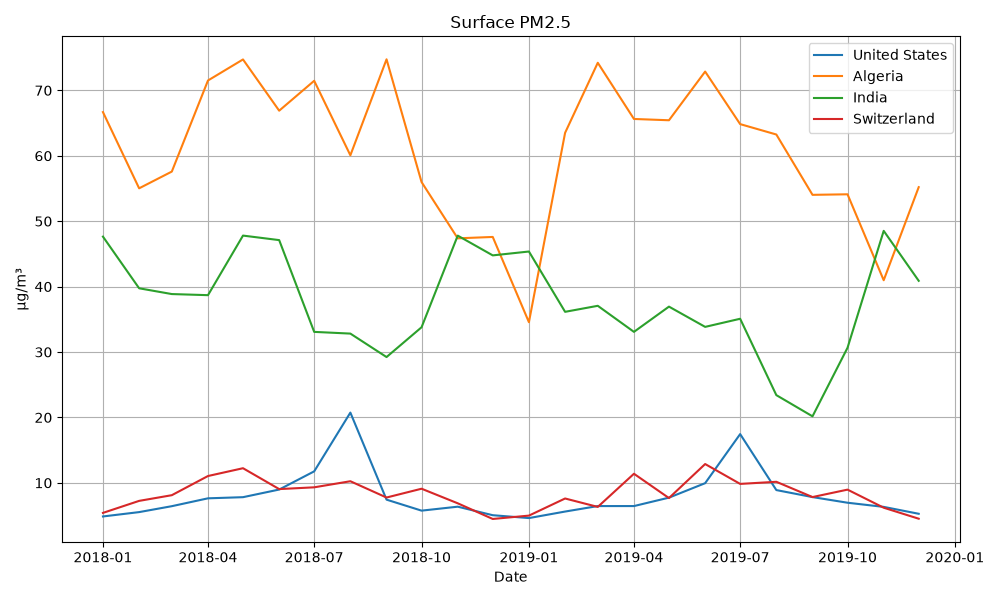

In [10]:
# Plot monthly mean PM2.5 for selected countries
fig, ax = plt.subplots(figsize=(10, 6))

countries = ['United_States', 'Algeria', 'India', 'Switzerland']

for country in countries:
    ax.plot(dat['date'], dat[country], label=country.replace('_', ' '))

ax.set_title('Surface PM2.5')
ax.set_xlabel('Date')
ax.set_ylabel('μg/m³')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Get annual average PM2.5 per country
plotyear = 2019
idat = dat.loc[(dat['date']>=datetime(plotyear,1,1))&(dat['date']<datetime(plotyear+1,1,1))].mean(axis=0,numeric_only=True).reset_index().rename(columns={'index':'country',0:'pm25'})

#Download world_json to the working directory, source url: https://geojson-maps.ash.ms/
world_json = 'custom.geo.json'
with open(world_json) as f:
    world = json.load(f) 

# To handle countries missing in the PM2.5 data frame (because the netCDF mask file does not include these new countries yet). 
new_countries = {
    'S._Sudan':'Sudan',
    'Somaliland':'Somalia',
    'Congo':'Democratic_Republic_of_the_Congo',
    'N._Cyprus':'Cyprus',
    'Kosovo':'Serbia',
    'Montenegro':'Serbia',
    'W._Sahara':'Mauritania',
    'Timor-Leste':'Indonesia',
}

# Create new entries for all new countries using the value from the 'old' country as a proxy
new_entries = pd.concat(
    [pd.DataFrame({'country': [cname], 'pm25': idat.loc[idat.country == new_countries[cname], 'pm25'].values})
     for cname in new_countries]
)

# Combine the new entries with the original data
idat = pd.concat([idat, new_entries], ignore_index=True)
country_list = list(idat.country.values)
 
# To handle differences in naming convention
country_mapper = {
    'Bahamas':'The_Bahamas',
    'Dominican_Rep.':'Dominican_Republic',
    'Falkland_Is.':'Falkland_Islands',
    'Korea':'North_Korea',
    'Dem._Rep._Korea':'South_Korea',
    'Lao_PDR':'Laos',
    "Côte_d'Ivoire":'Ivory_Coast',
    'Central_African_Rep.':'Central_African_Republic',
    'Dem._Rep._Congo':'Democratic_Republic_of_the_Congo',
    'Gambia':'The_Gambia',
    'Eq._Guinea':'Equatorial_Guinea',
    'Solomon_Is.':'Solomon_Islands',
    'Bosnia_and_Herz.':'Bosnia_and_Herzegovina',
    'Czechia':'Czech_Republic',
    'United_States_of_America':'United_States',
    'Ireland':'Republic_of_Ireland',
    'North_Macedonia':'Republic_of_Macedonia',
    'eSwatini':'Swaziland'
}

# create feature collection for all countries
found = []
missing = []
countries = []
for c in world['features']:
    cname = c['properties']['name'].replace(' ','_')
    cname = country_mapper[cname] if cname in country_mapper else cname
    if cname in country_list:
        found.append(cname)
        countries.append({'type':'Feature','geometry':c['geometry'],'id':cname})
    else:
        missing.append(cname)
    
geo_world = {'type': 'FeatureCollection','features': countries}

# Fix Eswatini misspelling
idat.country = idat.country.replace('Swaziland', 'Eswatini')

for i in range(len(geo_world['features'])):
    if geo_world['features'][i]['id'] == 'Swaziland':
        geo_world['features'][i]['id'] = 'Eswatini'

# plot PM2.5 per country
fig = px.choropleth(idat,geojson=geo_world,locations='country',color=idat['pm25'],title='Annual Average Surface PM2.5 ({})'.format(plotyear))
fig.show()

**7. Write to csv file:**

In [ ]:
%%time
## find the last day in the ending time
year = time2.strftime("%Y")
mon = time2.strftime("%m")
day = calendar.monthrange(int(year), int(mon))[1]
daterange_str=time1.strftime("%Y%m%d")+'-'+time2.strftime("%Y%m")+str(day)

##File path where csv will be written
ofile = newpath+'/test_PM25_'+daterange_str+'.csv'

##write custom header
header = "######################################################################################\n"
header += "## This is the sample data file for:\n"
header += "## ProductProduct = M2_TMAX_PM25 \n"
header += "## Version = 1 \n"
header += "## Title = MERRA-2 avgM_2d_pm25_admin0 2d Single-Level Country-Level Surface PM2.5 Monthly Mean Product \n"
#header += "## ** File: MERRA2.avgM_2d_pm25_admin0.v01.{}.xlsx \n".format(daterange_str)
#header += "## ** File: MERRA2.avsgM_2d_pm25_admin0_pw.v01.{}.xlsx \n".format(daterange_str)
header += time1.strftime("## RangeBeginningDate = %Y-%m-%d\n")
header += time2.strftime("## RangeEndingDate = %Y-%m-")+str(day)+"\n"
header += datetime.today().strftime("## Created Time = %Y-%m-%d %H:%M \n")
header += "## Number of lines = {:d}\n".format(dat.shape[0])
header += "## Number of columns = {:d}\n".format(dat.shape[1])
header += "## FillValue = NaN \n"
header += "## Units = micro-grams/m3 \n"
header += "#####################################################################################\n"

with open(ofile,'w') as f:
    f.write(header)
    
# Write data to file
dat.to_csv(ofile,index=False,header=True,date_format='%Y-%m',float_format='%.1f',na_rep='NaN',mode='a')
print('file written to {}'.format(ofile) )

file written to MERRA2_2023-05-12/test_PM25_20180101-20191231.csv
CPU times: user 14.4 ms, sys: 3.08 ms, total: 17.4 ms
Wall time: 17.3 ms


### Contributors ###


The code in this document was contributed by<br> 
Christoph Keller (GSFC GMAO/USRA)<br>
Kanan Patel (U Texas at Austin/SSAI Intern)<br>
Suhung Shen (GSFC GES DISC/GMU)<br>
Helen Amos (GSFC Applied Sciences/SSAI)<br>

Updated and Edited by Chris Battisto in May 2023 (GSFC GES DISC)


### Related Links ###

- Download [shape files](https://www.weather.gov/gis/Counties)
- Download [world_geo_json file](https://geojson-maps.ash.ms/)
